# Fine-tuning Qwen3-14B on lookup-and-confirm data

**Experiment.** Train a fresh LoRA on the 14B base model with the 180 teacher conversations **augmented** so that the agent (1) opens **every** order of the customer before any change and (2) asks for an explicit **yes** before every database change. Same recipe as the earlier "new" model (r=16, lr 5e-5, batch 8, 1 epoch), so the only difference is the data. Then run the τ-bench retail test (GPT-4o user, 115 tasks, **4 trials per task**, temperature 0.7, the same setup as the earlier runs) and compare with the starting adapter (41.7% pass^1) and the distilled model (45.7%) measured the same way.

This notebook only **reads** `full_run_results/aug_sft_run.json`, rewritten every 30 s by `sft_aug/update_aug_json.py` (start it with `sft_aug/aug_json_updater.sh start`). Re-run a cell to refresh.

---
# Part 1: process info

In [1]:
import json, datetime
from pathlib import Path
from IPython.display import HTML, display
ROOT = Path("..") if Path("../full_run_results").exists() else Path(".")
PATH = ROOT / "full_run_results" / "aug_sft_run.json"
load = lambda: json.load(open(PATH))
def fmt_min(m):
    if m is None: return "-"
    m = int(round(m)); return f"{m} min" if m < 60 else f"{m // 60} h {m % 60:02d} min"
def table(rows, head=None):
    td = "style='padding:3px 12px;border-bottom:1px solid #ddd;text-align:left'"
    h = "".join(f"<th {td}>{c}</th>" for c in head) if head else ""
    b = "".join("<tr>" + "".join(f"<td {td}>{c}</td>" for c in r) + "</tr>" for r in rows)
    return f"<table style='border-collapse:collapse;margin:6px 0 14px'>{('<tr>' + h + '</tr>') if head else ''}{b}</table>"
def info_html(r):
    p, t, c = r.get("pod", {}), r["training"], r["config"]
    o = [f"<h4>JSON written {r['updated']} &middot; stage: <span style='color:#1E7A5C'>{r['stage']}</span></h4>"]
    if not r.get("pod_reachable", True): o.append("<p style='color:#B3261E'><b>Pod unreachable</b>, showing the last known state.</p>")
    o.append("<b>Machine</b>" + table([["address", p.get("host")], ["GPU", p.get("gpu_name")], ["GPU load / memory / temperature", f"{p.get('gpu_util_pct')} / {p.get('gpu_mem_used')} of {p.get('gpu_mem_total')} / {p.get('gpu_temp_c')} C"],
        ["disk (size, used, free)", p.get("disk")]]))
    o.append("<b>Experiment</b>" + table([[k.replace("_", " "), v] for k, v in c.items()]))
    pct = f"{t['steps_done'] / t['steps_total']:.0%}" if t["steps_total"] else "-"
    ref = 193.3 / 384
    o.append("<b>Progress</b>" + table([["steps", f"{t['steps_done']} / {t['steps_total']} ({pct})"], ["elapsed", fmt_min(t["elapsed_min"])],
        ["seconds per step (reference run: 29.4)", f"{t['sec_per_step']:.1f}" if t["sec_per_step"] else "-"], ["time left", fmt_min(t["eta_min"])], ["training done at about (local)", t.get("eta_at") or "-"],
        ["checkpoints saved", ", ".join(t["checkpoints"]) or "-"]]))
    pl = r.get("plan")
    if pl:
        o.append("<b>Remaining time (training and evaluation)</b>" + table([[x["step"], fmt_min(x["minutes"]) if x["minutes"] else "done", x["basis"], x["done_at"] or "-"] for x in pl["steps"]], ["phase", "time left", "basis", "done at (local)"])
                 + f"<p>everything done, results on the Mac, at about <b>{pl['done_at']}</b> ({fmt_min(pl['total_min'])} from now)</p>")
    ev_ = r.get("eval", {})
    if ev_.get("rollouts_done"):
        o.append("<b>Evaluation progress</b>" + table([["rollouts", f"{ev_['rollouts_done']} / {ev_['rollouts_total']}"], ["pass^1 so far", f"{ev_['pass1']:.1%}"],
            ["rollouts per minute", f"{ev_['rollouts_per_min']:.2f}" if ev_.get("rollouts_per_min") else "-"], ["done at about", ev_.get("eta_at") or "-"]]))
    o.append("<b>Last lines of the training log</b><pre style='font-size:12px'>" + "\n".join(l.replace("<", "&lt;") for l in (p.get("train_log_tail") or p.get("env_tail") or [])) + "</pre>")
    o.append("<b>Recent events</b>" + table([[e["time"], e["event"].replace("<", "&lt;")] for e in r.get("events", [])[-10:]]))
    return "".join(o)
RUN = load(); display(HTML(info_html(RUN)))

address,root@195.26.233.55:43757
GPU,NVIDIA A100-SXM4-80GB
GPU load / memory / temperature,0 % / 71595 MiB of 81920 MiB / 29 C
"disk (size, used, free)",overlay 50G 17G 34G 34% /
base,unsloth/Qwen3-14B-unsloth-bnb-4bit (fresh LoRA r=16)
data,"teacher32b_passed_sft_lookups_confirm.json (178 conversations, 4086 samples)"
lr,5e-05
batch,8
epochs,1
max tokens,20000
reference run,"distill-epoch-1: 384 steps, 193 min on an A100"


### Live view (optional): refreshes the block above every 30 s until you stop the cell

In [19]:
import time
from IPython.display import clear_output
try:
    while True:
        RUN = load(); clear_output(wait=True); display(HTML(info_html(RUN)))
        if str(RUN["stage"]).startswith(("training finished", "failed")): break
        time.sleep(30)
except KeyboardInterrupt:
    pass

address,root@195.26.233.55:43757
GPU,NVIDIA A100-SXM4-80GB
GPU load / memory / temperature,0 % / 71595 MiB of 81920 MiB / 29 C
"disk (size, used, free)",overlay 50G 17G 34G 34% /
base,unsloth/Qwen3-14B-unsloth-bnb-4bit (fresh LoRA r=16)
data,"teacher32b_passed_sft_lookups_confirm.json (178 conversations, 4086 samples)"
lr,5e-05
batch,8
epochs,1
max tokens,20000
reference run,"distill-epoch-1: 384 steps, 193 min on an A100"


---
# Part 2: graphs (matplotlib)

In [2]:
import numpy as np, matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#B8B8B8", "axes.grid": True, "grid.color": "#E6E6E6",
                     "grid.linewidth": 0.8, "axes.axisbelow": True, "lines.linewidth": 2, "legend.frameon": False, "xtick.color": "#555", "ytick.color": "#555"})
RUN = load(); T = RUN["training"]
C_AUG, C_REF = "#1E7A5C", "#2F5D8A"
REF = json.load(open(ROOT / "full_run_results" / "distill_run.json"))["training"]   # the earlier 'new' model's SFT
def smooth(x, k=20):
    x = np.asarray(x, float); return np.convolve(x, np.ones(k) / k, mode="valid") if len(x) >= k else x
def placeholder(title, text="no data yet"):
    fig, ax = plt.subplots(figsize=(10, 2.2)); ax.set_title(title); ax.axis("off")
    ax.text(0.5, 0.5, text, ha="center", va="center", fontsize=14, color="#888", transform=ax.transAxes); plt.show()
def bar_labels(ax, bars, fmt="{:.0%}", errs=None):   # value above each bar (above the error cap if there is one)
    for b, e in zip(bars, errs if errs is not None else [0] * len(bars)):
        ax.annotate(fmt.format(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_y() + b.get_height() + (e or 0)), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, color="#333")
    if ax.get_autoscaley_on(): ax.margins(y=0.12)
def legend_below(fig, ncol=4):
    h, l = [], []
    for ax in fig.axes:
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l and not ll.startswith("_"): h.append(hh); l.append(ll)
    if h: fig.legend(h, l, loc="lower center", ncol=ncol, bbox_to_anchor=(0.5, -0.02)); fig.tight_layout(rect=(0, 0.08, 1, 1))
    else: fig.tight_layout()
print(f"stage: {RUN['stage']} | steps {T['steps_done']}/{T['steps_total']}")

stage: finished (training and evaluation) | steps 511/511


### 1. Loss: this run vs the earlier run (different data, so compare the shape, not the level)

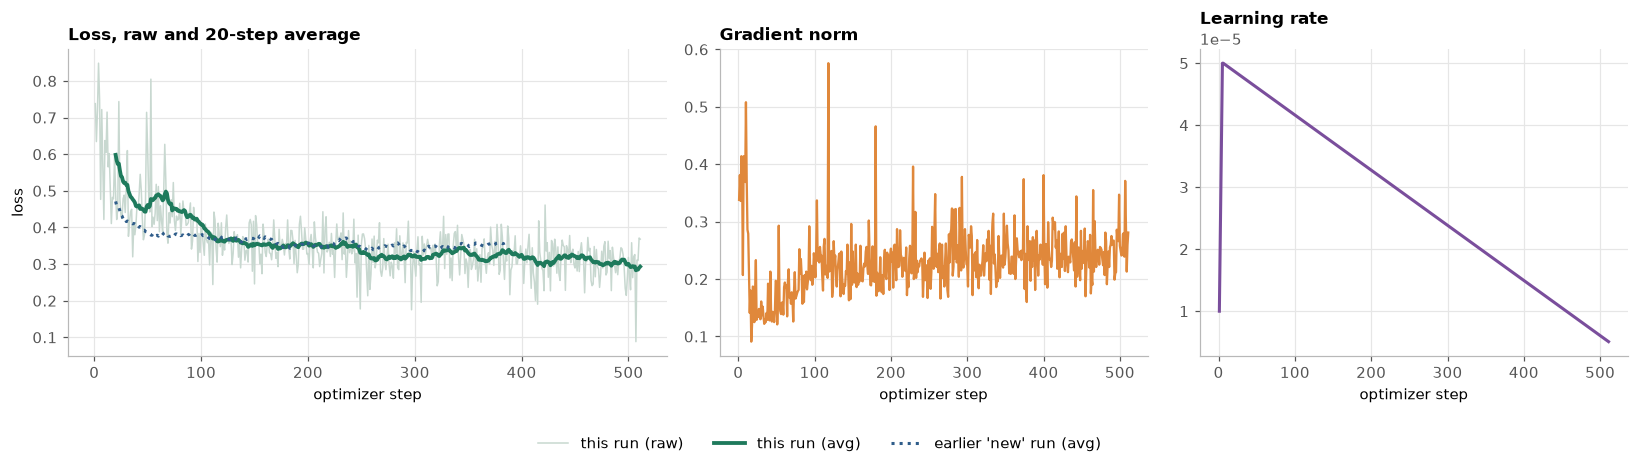

In [3]:
if T["step"]:
    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw=dict(width_ratios=[1.4, 1, 1]))
    a1.plot(T["step"], T["loss"], color="#C8D8D0", lw=1, label="this run (raw)")
    s = smooth(T["loss"]); a1.plot(T["step"][len(T["step"]) - len(s):], s, color=C_AUG, lw=2.5, label="this run (avg)")
    rs = smooth(REF["loss"]); a1.plot(REF["step_index"][len(REF["step_index"]) - len(rs):], rs, color=C_REF, ls=":", label="earlier 'new' run (avg)")
    a1.set_title("Loss, raw and 20-step average"); a1.set_ylabel("loss")
    a2.plot(T["step"], T["grad_norm"], color="#E0883B", lw=1.5); a2.set_title("Gradient norm")
    a3.plot(T["step"], T["lr"], color="#7A4E9C"); a3.set_title("Learning rate"); a3.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    for a in (a1, a2, a3): a.set_xlabel("optimizer step")
    legend_below(fig, 3); plt.show()
else:
    placeholder("Loss", "training has not logged a step yet")

### Loss function (training loss on the assistant turns, per optimizer step)

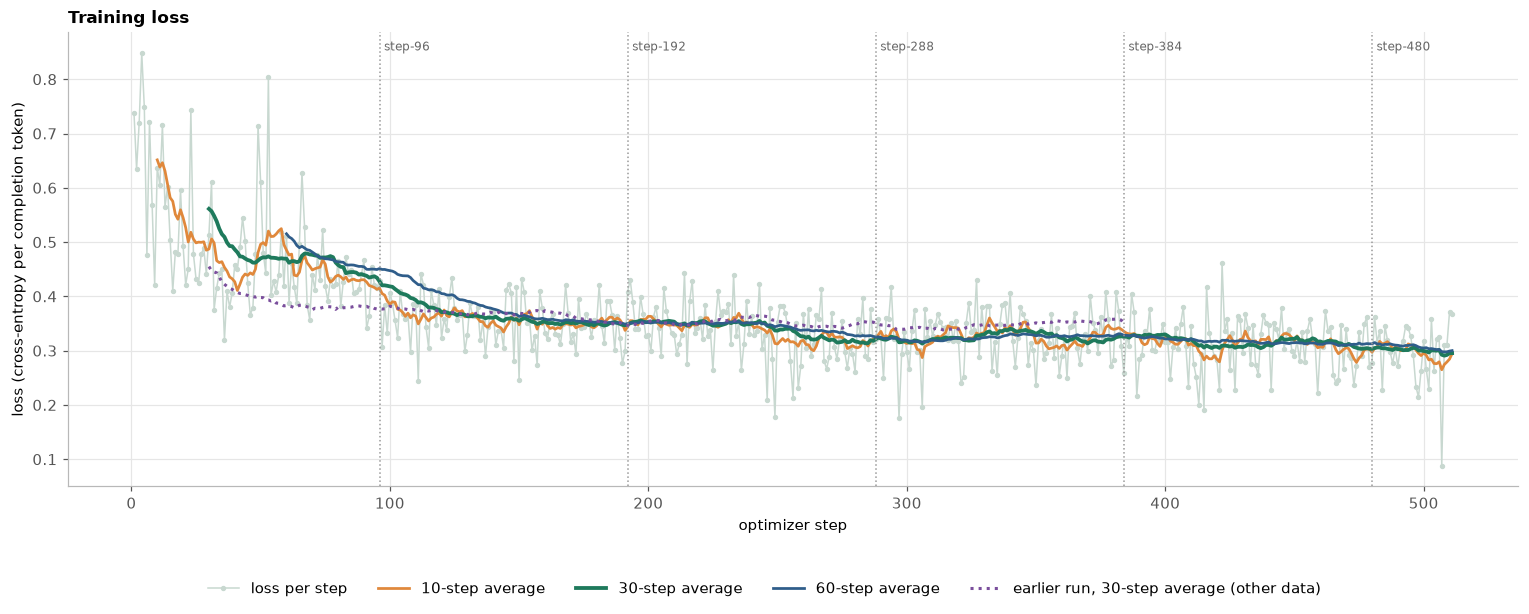

first 10 steps: 0.651 | latest 10 steps: 0.295 | lowest single step: 0.088 at step 507 | steps logged: 511


In [4]:
if len(T["step"]) > 1:
    st = np.array(T["step"]); ls = np.array(T["loss"], float)
    fig, ax = plt.subplots(figsize=(14, 5.5))
    ax.plot(st, ls, color="#C8D8D0", lw=1, marker="o", ms=2.5, label="loss per step")
    for k, col in ((10, "#E0883B"), (30, C_AUG), (60, "#2F5D8A")):
        if len(ls) >= k:
            sm = smooth(ls, k); ax.plot(st[len(st) - len(sm):], sm, color=col, lw=2.5 if k == 30 else 1.8, label=f"{k}-step average")
    rs = smooth(REF["loss"], 30); ax.plot(REF["step_index"][len(REF["step_index"]) - len(rs):], rs, color="#7A4E9C", ls=":", label="earlier run, 30-step average (other data)")
    for ck in (96, 192, 288, 384, 480):
        if ck <= st[-1]:
            ax.axvline(ck, color="#999", ls=":", lw=1); ax.annotate(f"step-{ck}", (ck, 1), xycoords=("data", "axes fraction"), xytext=(3, -12), textcoords="offset points", fontsize=8, color="#666")
    ax.set_title("Training loss"); ax.set_xlabel("optimizer step"); ax.set_ylabel("loss (cross-entropy per completion token)")
    legend_below(fig, 5); plt.show()
    n = min(10, len(ls)); print(f"first {n} steps: {ls[:n].mean():.3f} | latest {n} steps: {ls[-n:].mean():.3f} | lowest single step: {ls.min():.3f} at step {int(st[ls.argmin()])} | steps logged: {len(ls)}")
else:
    placeholder("Loss function", "training has not logged a step yet")

### 2. Speed and time left

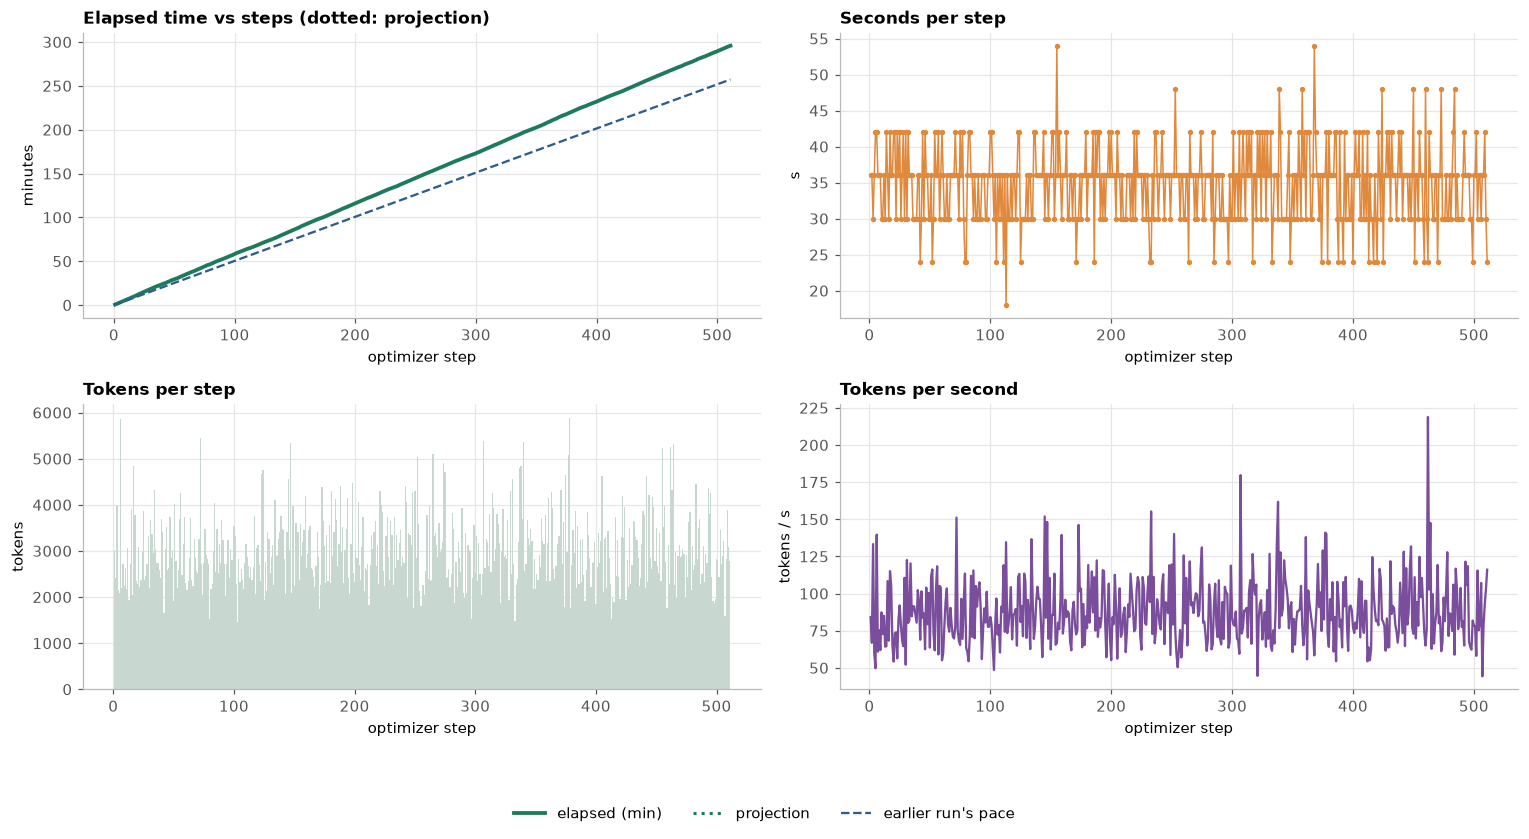

projected total: 4.9 h (earlier run: 3.2 h for 384 steps)


In [5]:
if len(T["step"]) > 1:
    el = np.array(T["elapsed"]); st = np.array(T["step"]); dt = np.diff(el, prepend=0) * 60; tok = np.array(T["tokens"])
    fig, ((a1, a2), (a3, a4)) = plt.subplots(2, 2, figsize=(14, 7.5))
    a1.plot(st, el, color=C_AUG, lw=2.5, label="elapsed (min)")
    rate = el[-1] / st[-1]; a1.plot([st[-1], T["steps_total"]], [el[-1], rate * T["steps_total"]], color=C_AUG, ls=":", label="projection")
    a1.plot([0, T["steps_total"]], [0, 193.3 / 384 * T["steps_total"]], color=C_REF, ls="--", lw=1.5, label="earlier run's pace")
    a1.set_title("Elapsed time vs steps (dotted: projection)"); a1.set_ylabel("minutes")
    a2.plot(st, dt, color="#E0883B", lw=1, marker="o", ms=2.5); a2.set_title("Seconds per step"); a2.set_ylabel("s")
    a3.bar(st, tok, color="#C8D8D0", width=1.0); a3.set_title("Tokens per step"); a3.set_ylabel("tokens")
    a4.plot(st, tok / np.maximum(dt, 1e-9), color="#7A4E9C", lw=1.5); a4.set_title("Tokens per second"); a4.set_ylabel("tokens / s")
    for a in (a1, a2, a3, a4): a.set_xlabel("optimizer step")
    legend_below(fig, 3); plt.show()
    print(f"projected total: {rate * T['steps_total'] / 60:.1f} h (earlier run: 3.2 h for 384 steps)")
else:
    placeholder("Speed", "needs at least 2 logged steps")

### 3. GPU right now

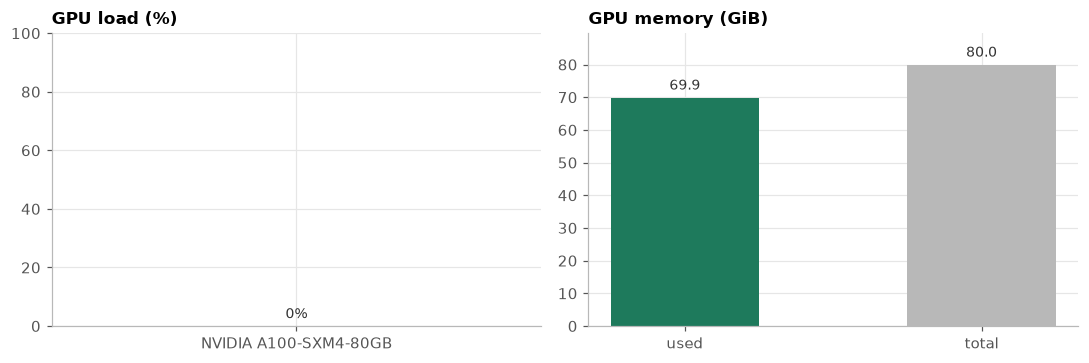

In [6]:
P = RUN["pod"]
def num(s):
    try: return float(str(s).split()[0].replace("%", ""))
    except Exception: return None
used, tot = num(P.get("gpu_mem_used")), num(P.get("gpu_mem_total"))
if used is not None and tot:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4))
    b = a1.bar([P.get("gpu_name")], [num(P.get("gpu_util_pct")) or 0], color=C_AUG, width=0.5); a1.set_ylim(0, 100); a1.set_title("GPU load (%)"); bar_labels(a1, b, "{:.0f}%")
    b = a2.bar(["used", "total"], [used / 1024, tot / 1024], color=[C_AUG, "#B8B8B8"], width=0.5); a2.set_title("GPU memory (GiB)"); bar_labels(a2, b, "{:.1f}")
    fig.tight_layout(); plt.show()
else:
    placeholder("GPU", "pod not reporting")

### 4. What is in the training data: original vs augmented

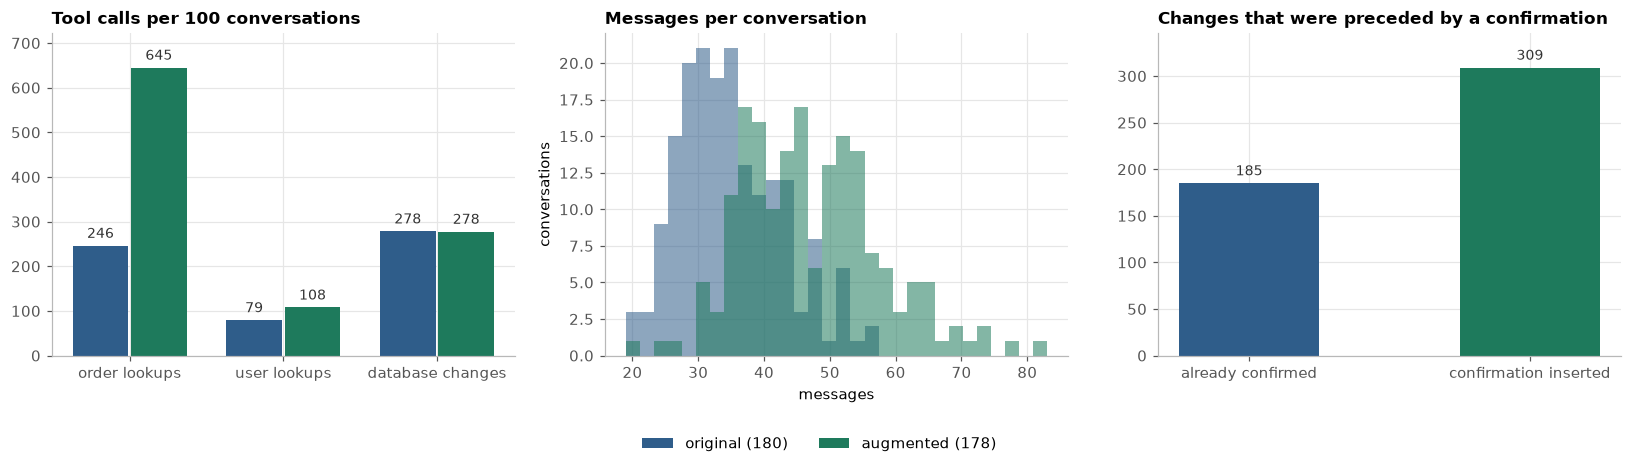

{'conversations_in': 180, 'lookups_inserted': 710, 'user_details_inserted': 50, 'writes': 494, 'writes_already_confirmed': 185, 'confirmations_inserted': 309, 'conversations_out': 178, 'avg_messages_before': 36.05555555555556, 'avg_messages_after': 48.0}
dropped conversations: [21, 109]


In [7]:
SA = ROOT / "sft_aug"
stats = json.load(open(SA / "teacher32b_passed_sft_lookups_confirm_stats.json"))
orig = json.load(open(SA / "teacher32b_passed_sft_reasoning.json")); aug = json.load(open(SA / "teacher32b_passed_sft_lookups_confirm.json"))
WRITE = {"cancel_pending_order","exchange_delivered_order_items","modify_pending_order_address","modify_pending_order_items","modify_pending_order_payment","modify_user_address","return_delivered_order_items"}
count = lambda convs, names: sum(1 for c in convs for m in c["messages"] for t in (m.get("tool_calls") or []) if t["function"]["name"] in names)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4.2))
cats = ["order lookups", "user lookups", "database changes"]; x = np.arange(len(cats)); w = 0.38
lens = {}
for j, (name, convs, color) in enumerate((("original (180)", orig, C_REF), ("augmented (178)", aug, C_AUG))):
    n = len(convs)
    b = a1.bar(x + (j - 0.5) * w, [100 * count(convs, {"get_order_details"}) / n, 100 * count(convs, {"get_user_details"}) / n, 100 * count(convs, WRITE) / n], w * 0.95, color=color, label=name)
    bar_labels(a1, b, "{:.0f}"); lens[name] = ([len(c["messages"]) - 1 for c in convs], color)
a1.set_xticks(x, cats); a1.set_title("Tool calls per 100 conversations")
bins = np.histogram_bin_edges(np.concatenate([v for v, _ in lens.values()]), 30)
for name, (v, color) in lens.items(): a2.hist(v, bins=bins, color=color, alpha=0.55, label="_" + name)
a2.set_title("Messages per conversation"); a2.set_xlabel("messages"); a2.set_ylabel("conversations")
b = a3.bar(["already confirmed", "confirmation inserted"], [stats["writes_already_confirmed"], stats["confirmations_inserted"]], color=[C_REF, C_AUG], width=0.5); bar_labels(a3, b, "{:.0f}")
a3.set_title("Changes that were preceded by a confirmation")
legend_below(fig, 2); plt.show()
print({k: v for k, v in stats.items() if not isinstance(v, list)}); print("dropped conversations:", stats.get("dropped_changed_before_authenticating"))

---
# Part 3: evaluation (fills in as the evaluation runs, then finishes after training)
Same test as the earlier runs: τ-bench retail test split, 115 tasks, **4 trials per task**, temperature 0.7, GPT-4o as the customer, 25 steps. Baselines are the two completed 4-trial runs: the **starting adapter (control, same pod)** and the **distilled model**. The new model's results come from `/root/passk_aug.jsonl` on the pod while it runs (via the JSON), and from the saved files after I copy them.

In [8]:
import math, re
DATA = ROOT / "sft_aug" / "data"
def load_results(path):
    by = {}
    for l in open(path):
        r = json.loads(l); by.setdefault(r["task_index"], {})[r["trial"]] = 1 if r["reward"] >= 1 else 0
    return {t: [v[k] for k in sorted(v)] for t, v in by.items()}
def load_rows(path): return sorted((json.loads(l) for l in open(path)), key=lambda r: r["finished_at"])
RES = {"starting adapter (control)": DATA / "retail_starting_adapter_rerun_4trials_results.jsonl", "distilled (earlier)": DATA / "retail_new_model_4trials_results.jsonl"}
BY = {k: load_results(v) for k, v in RES.items()}
ROWS = {k: load_rows(v) for k, v in RES.items()}
final_aug = DATA / "retail_aug_4trials_results.jsonl"
E = RUN.get("eval", {})
if final_aug.exists():
    BY["augmented (this run)"] = load_results(final_aug); ROWS["augmented (this run)"] = load_rows(final_aug)
elif E.get("rollouts_done"):
    BY["augmented (this run)"] = {int(t): v for t, v in E["by_task"].items()}
def passk(v, k): return math.comb(sum(v), k) / math.comb(len(v), k) if len(v) >= k else None
def mean_se(xs):
    xs = list(xs); n = len(xs)
    if not n: return None, None
    m = sum(xs) / n; return m, (math.sqrt(sum((x - m) ** 2 for x in xs) / (n - 1) / n) if n > 1 else None)
SUMM = {k: {kk: mean_se(passk(v, kk) for v in by.values() if passk(v, kk) is not None) for kk in (1, 2, 3, 4)} for k, by in BY.items()}
COL = {"starting adapter (control)": "#E0883B", "distilled (earlier)": "#2F5D8A", "augmented (this run)": "#1E7A5C"}
prog = f"{E.get('rollouts_done', 0)}/{E.get('rollouts_total', 460)} rollouts" + (f", about {fmt_min(E.get('eta_min'))} left, done at about {E.get('eta_at')}" if E.get("eta_min") else "")
print("augmented model evaluation:", "finished (saved file)" if final_aug.exists() else prog)

augmented model evaluation: finished (saved file)


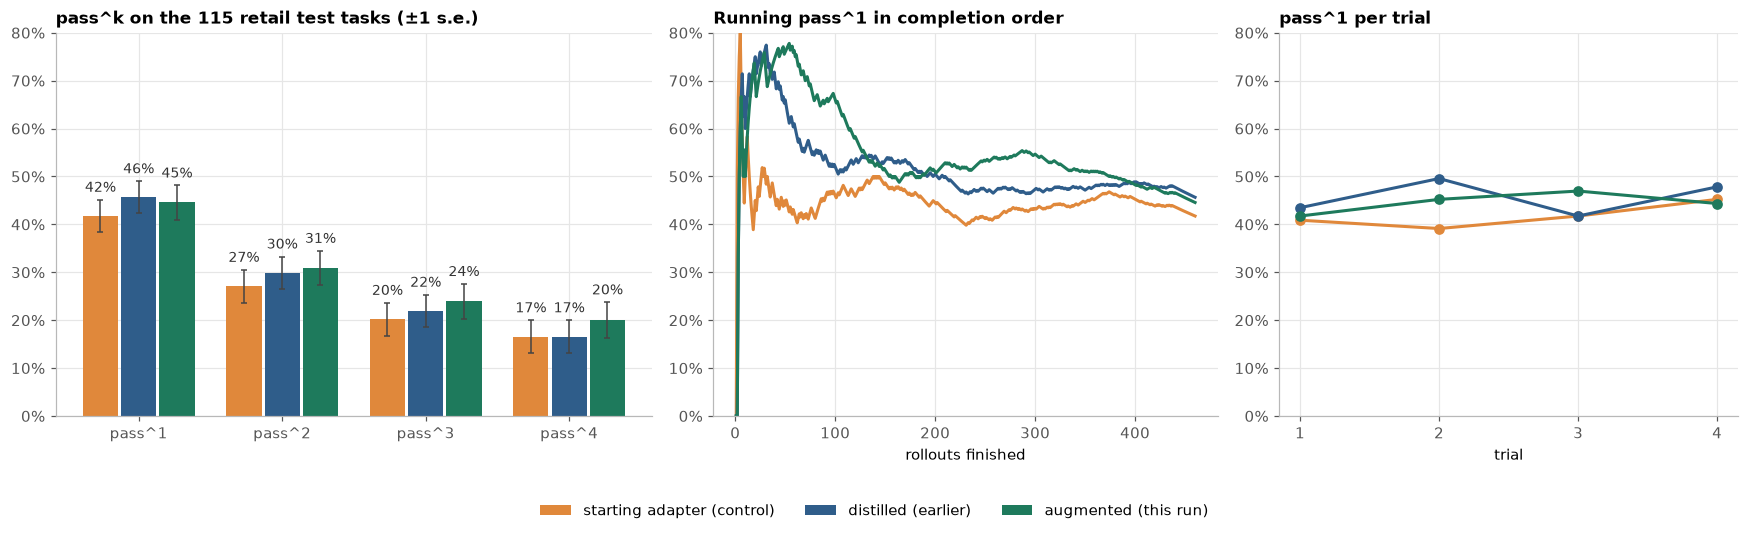

In [9]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw=dict(width_ratios=[1.3, 1.1, 1]))
w = 0.8 / len(SUMM)
for j, (name, S) in enumerate(SUMM.items()):
    ks = [k for k in (1, 2, 3, 4) if S[k][0] is not None]
    b = a1.bar(np.array(ks) - 1 + (j - (len(SUMM) - 1) / 2) * w, [S[k][0] for k in ks], w * 0.92, yerr=[S[k][1] or 0 for k in ks], color=COL[name], label=name,
               error_kw=dict(ecolor="#444", elinewidth=1, capsize=2)); bar_labels(a1, b, errs=[S[k][1] or 0 for k in ks])
a1.set_xticks(range(4), [f"pass^{k}" for k in (1, 2, 3, 4)]); a1.set_title("pass^k on the 115 retail test tasks (±1 s.e.)")
for name, rows in ROWS.items():
    ok = np.array([1 if r["reward"] >= 1 else 0 for r in rows]); a2.plot(np.arange(1, len(ok) + 1), np.cumsum(ok) / np.arange(1, len(ok) + 1), color=COL[name], lw=2, label="_" + name)
if not final_aug.exists() and E.get("running_pass1"):
    a2.plot(np.arange(1, len(E["running_pass1"]) + 1), E["running_pass1"], color=COL["augmented (this run)"], lw=2, label="_augmented (running)")
a2.set_title("Running pass^1 in completion order"); a2.set_xlabel("rollouts finished")
for name, rows in ROWS.items():
    tr = {}
    for r in rows: tr.setdefault(r["trial"], []).append(1 if r["reward"] >= 1 else 0)
    a3.plot([k + 1 for k in sorted(tr)], [sum(tr[k]) / len(tr[k]) for k in sorted(tr)], color=COL[name], marker="o", ms=6, label="_" + name)
if not final_aug.exists() and E.get("per_trial"):
    a3.plot([int(k) + 1 for k in E["per_trial"]], [v["passed"] / v["done"] for v in E["per_trial"].values()], color=COL["augmented (this run)"], marker="o", ms=6, label="_aug")
a3.set_title("pass^1 per trial"); a3.set_xlabel("trial"); a3.set_xticks([1, 2, 3, 4])
for a in (a1, a2, a3): a.set_ylim(0, 0.8); a.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
legend_below(fig, 3); plt.show()

In [10]:
# paired comparison on tasks that have all 4 trials (needs the augmented run to be complete)
rng = np.random.default_rng(0)
def paired(a, b):
    ts = [t for t in a if t in b and len(a[t]) == 4 and len(b[t]) == 4]
    xs = np.array([np.mean(a[t]) - np.mean(b[t]) for t in ts])
    if len(xs) < 20: return None
    boots = np.array([rng.choice(xs, len(xs)).mean() for _ in range(10000)]); flips = np.array([(xs * rng.choice([-1, 1], len(xs))).mean() for _ in range(10000)])
    return dict(n=len(xs), mean=xs.mean(), lo=np.percentile(boots, 2.5), hi=np.percentile(boots, 97.5), p=float((np.abs(flips) >= abs(xs.mean())).mean()))
A = "augmented (this run)"
if A in BY and final_aug.exists():
    rows_ = []
    for other in ("starting adapter (control)", "distilled (earlier)"):
        r = paired(BY[A], BY[other]); rows_.append([f"augmented vs {other}", r["n"], f"{r['mean']:+.3f}", f"{r['lo']:+.3f} to {r['hi']:+.3f}", f"{r['p']:.3f}"])
    display(HTML("<b>Paired by task, pass^1 difference</b>" + table(rows_, ["comparison", "tasks", "difference", "95% bootstrap interval", "permutation p"])))
else:
    display(HTML("<p><i>Paired tests appear once the augmented evaluation is complete and its files are saved.</i></p>"))

comparison,tasks,difference,95% bootstrap interval,permutation p
augmented vs starting adapter (control),115,+0.028,-0.026 to +0.087,0.365
augmented vs distilled (earlier),115,-0.011,-0.057 to +0.037,0.721


### Behavior measures: did the model learn the habits? (from the saved conversations)

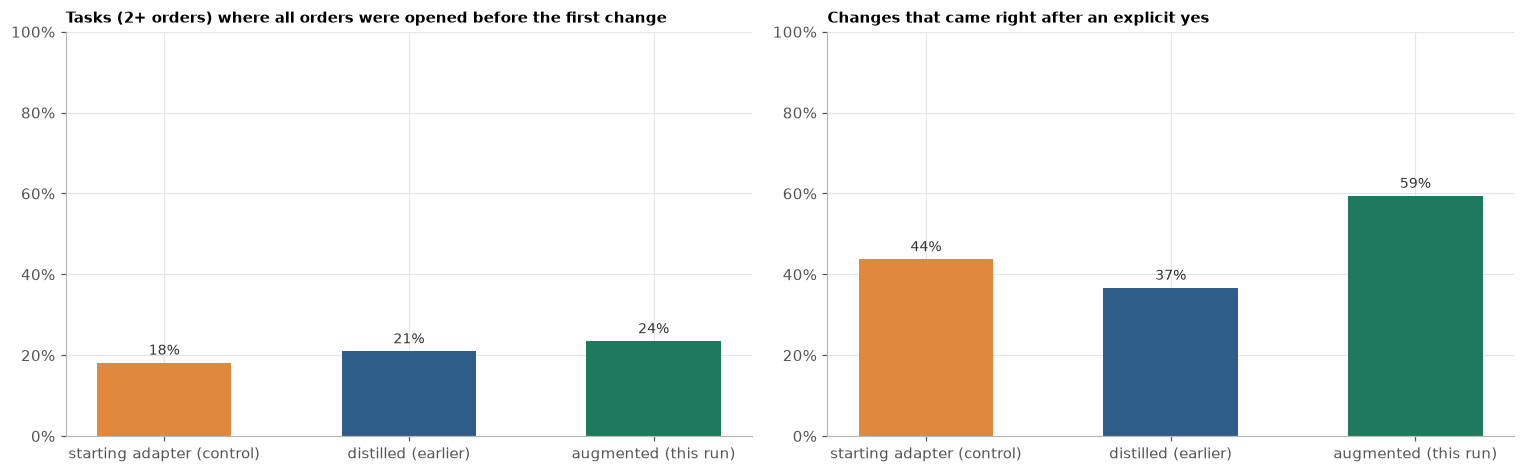

model,all orders opened first,changes after a yes
starting adapter (control),18%,44%
distilled (earlier),21%,37%
augmented (this run),24%,59%


In [11]:
WRITE = {"cancel_pending_order","exchange_delivered_order_items","modify_pending_order_address","modify_pending_order_items","modify_pending_order_payment","modify_user_address","return_delivered_order_items"}
AFF = re.compile(r"^\W*(yes|yeah|yep|sure|ok|okay|go ahead|please (go|proceed|do)|proceed|confirm|correct|that'?s (right|correct)|absolutely|definitely)\b", re.I)
def behaviour(path):
    multi = all_open = writes = yes = 0
    for l in open(path):
        conv = json.loads(l); orders, opened, fw, last_user, calls = None, set(), None, "", {}
        for m in conv["messages"]:
            if m["role"] == "user": last_user = (m.get("content") or "").strip()
            for c in (m.get("tool_calls") or []):
                calls[c["id"]] = c["function"]; name = c["function"]["name"]
                if name == "get_order_details":
                    try: opened.add(json.loads(c["function"]["arguments"]).get("order_id"))
                    except Exception: pass
                if name in WRITE:
                    writes += 1; yes += bool(AFF.search(last_user))
                    if fw is None: fw = set(opened)
            if m["role"] == "tool" and m.get("name") == "get_user_details" and (m.get("content") or "").startswith("{"):
                try: orders = json.loads(m["content"]).get("orders")
                except Exception: pass
        if orders and len(orders) >= 2:
            multi += 1; all_open += (fw if fw is not None else opened) >= set(orders)
    return {"all orders opened first": all_open / max(multi, 1), "changes right after a yes": yes / max(writes, 1), "conversations": multi}
TR = {"starting adapter (control)": DATA / "retail_starting_adapter_rerun_4trials_transcripts.jsonl", "distilled (earlier)": DATA / "retail_new_model_4trials_transcripts.jsonl", A: DATA / "retail_aug_4trials_transcripts.jsonl"}
BEH = {k: (behaviour(v) if v.exists() else None) for k, v in TR.items()}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, key, title in zip(axes, ("all orders opened first", "changes right after a yes"), ("Tasks (2+ orders) where all orders were opened before the first change", "Changes that came right after an explicit yes")):
    have = [(n, r) for n, r in BEH.items() if r]
    b = ax.bar([n for n, _ in have], [r[key] for _, r in have], color=[COL[n] for n, _ in have], width=0.55); bar_labels(ax, b)
    ax.set_ylim(0, 1); ax.set_title(title, fontsize=10); ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
if BEH[A] is None: fig.text(0.5, 0.01, "augmented conversations are added after the evaluation is copied from the pod", ha="center", color="#888")
fig.tight_layout(); plt.show()
display(HTML(table([[k] + ([f"{v['all orders opened first']:.0%}", f"{v['changes right after a yes']:.0%}"] if v else ["-", "-"]) for k, v in BEH.items()], ["model", "all orders opened first", "changes after a yes"])))

---
# Part 4: tau3 retail with the default settings (baseline vs augmented)
After the τ-bench evaluation above, the same two models are tested on **τ³ (tau2-bench) retail** under its **default settings**: agent temperature **0**, up to **200 steps**, **GPT-4.1** as the simulated customer, all **114 tasks**, **2 trials** per task, the baseline (starting adapter) first and the augmented model second, one after the other. Earlier τ³ runs in this project used temperature 0.7 and 1 trial (starting adapter 53/114 = 46.5%, distilled model 55/114 = 48.2%), so they are shown as a reference only, not as a like-for-like comparison.

Data: `full_run_results/tau3_std_run.json`, rewritten every 30 s by `sft_aug/update_tau3std_json.py` (`sft_aug/std_json_updater.sh start`).

In [12]:
P4 = ROOT / "full_run_results" / "tau3_std_run.json"
def std_info_html(r):
    b, a, pod, cfg, pl = r["old"], r["new"], r.get("pod", {}), r["config"], r["plan"]
    o = [f"<h4>JSON written {r['updated']} &middot; stage: <span style='color:#1E7A5C'>{r['stage']}</span></h4>"]
    if not r.get("pod_reachable", True): o.append("<p style='color:#B3261E'><b>Pod unreachable</b>, showing the last known state.</p>")
    o.append("<b>Machine</b>" + table([["address", pod.get("host")], ["GPU (name, load, memory used, total)", pod.get("gpu") or "-"], ["disk", pod.get("disk") or "-"],
        ["vLLM answering", "yes" if pod.get("vllm_up") else "no"], ["processes alive", ", ".join(k for k, v in (pod.get("procs") or {}).items() if v) or "none"],
        ["last setup log line", (pod.get("setup_tail") or "-").replace("<", "&lt;")[-150:]]]))
    o.append("<b>Settings</b>" + table([[k.replace("_", " "), v] for k, v in cfg.items()]))
    rows = [[n, f"{e['rollouts_done']} / {e['rollouts_total']}", e.get("passed", "-"), f"{e['pass1']:.1%} &plusmn; {e['pass1_se']:.1%}" if e.get("pass1") is not None and e.get("pass1_se") is not None else "-",
             f"{e['rollouts_per_min']:.2f}" if e.get("rollouts_per_min") else "-", f"${e.get('user_cost', 0):.2f}" if e.get("rollouts_done") else "-"] for n, e in (("baseline (starting adapter)", b), ("augmented", a))]
    o.append("<b>Progress</b>" + table(rows, ["run", "rollouts done", "passed", "pass^1 (&plusmn; s.e.)", "rollouts / min", "GPT-4.1 cost"]))
    o.append(f"<b>Remaining</b> (pace used {pl['pace_used']:.2f} rollouts/min)" + table([[x["step"], x["remaining"], fmt_min(x["minutes"]) if x["remaining"] else "done", x["done_at"] or "-"] for x in pl["steps"]], ["step", "rollouts left", "time", "done at (local)"])
             + f"<p>both runs done at about <b>{pl.get('done_at') or '-'}</b> local (setup and vLLM startup add about 25 minutes before the first rollout)</p>")
    p = r.get("paired")
    if p: o.append("<b>Baseline vs augmented, task by task (all trials pooled per task is not used here: trial 1 of each)</b>" + table([["both pass", len(p["both_pass"])], ["only augmented passes", len(p["only_new"])], ["only baseline passes", len(p["only_old"])], ["neither", len(p["neither"])]]))
    o.append("<b>Recent events</b>" + table([[e["time"], e["event"].replace("<", "&lt;")] for e in r.get("events", [])[-10:]]))
    return "".join(o)
if P4.exists():
    R4 = json.load(open(P4)); display(HTML(std_info_html(R4)))
else:
    R4 = None; display(HTML("<p><i>The τ³ default-settings run has not started yet (no tau3_std_run.json).</i></p>"))

address,root@154.54.102.23:16842
"GPU (name, load, memory used, total)","NVIDIA A100-SXM4-80GB, 0 %, 71599 MiB, 81920 MiB"
disk,overlay 50G 16G 35G 31% /
vLLM answering,yes
processes alive,vllm
last setup log line,-
benchmark,"tau3 (tau2-bench) retail, 114 tasks (split base)"
agent temperature,0.0
max steps,200
user,gpt-4.1 (default temperature)
trials,2


In [ ]:
import time as _t
from IPython.display import clear_output as _clr
try:
    while P4.exists():
        R4 = json.load(open(P4)); _clr(wait=True); display(HTML(std_info_html(R4)))
        if str(R4["stage"]).startswith(("finished", "failed")): break
        _t.sleep(30)
except KeyboardInterrupt:
    pass

address,root@154.54.102.23:16842
"GPU (name, load, memory used, total)","NVIDIA A100-SXM4-80GB, 97 %, 71599 MiB, 81920 MiB"
disk,overlay 50G 16G 35G 31% /
vLLM answering,yes
processes alive,"tau2, vllm"
last setup log line,-
benchmark,"tau3 (tau2-bench) retail, 114 tasks (split base)"
agent temperature,0.0
max steps,200
user,gpt-4.1 (default temperature)
trials,2


### τ³ results: pass rate, how rollouts ended, and the earlier runs for reference

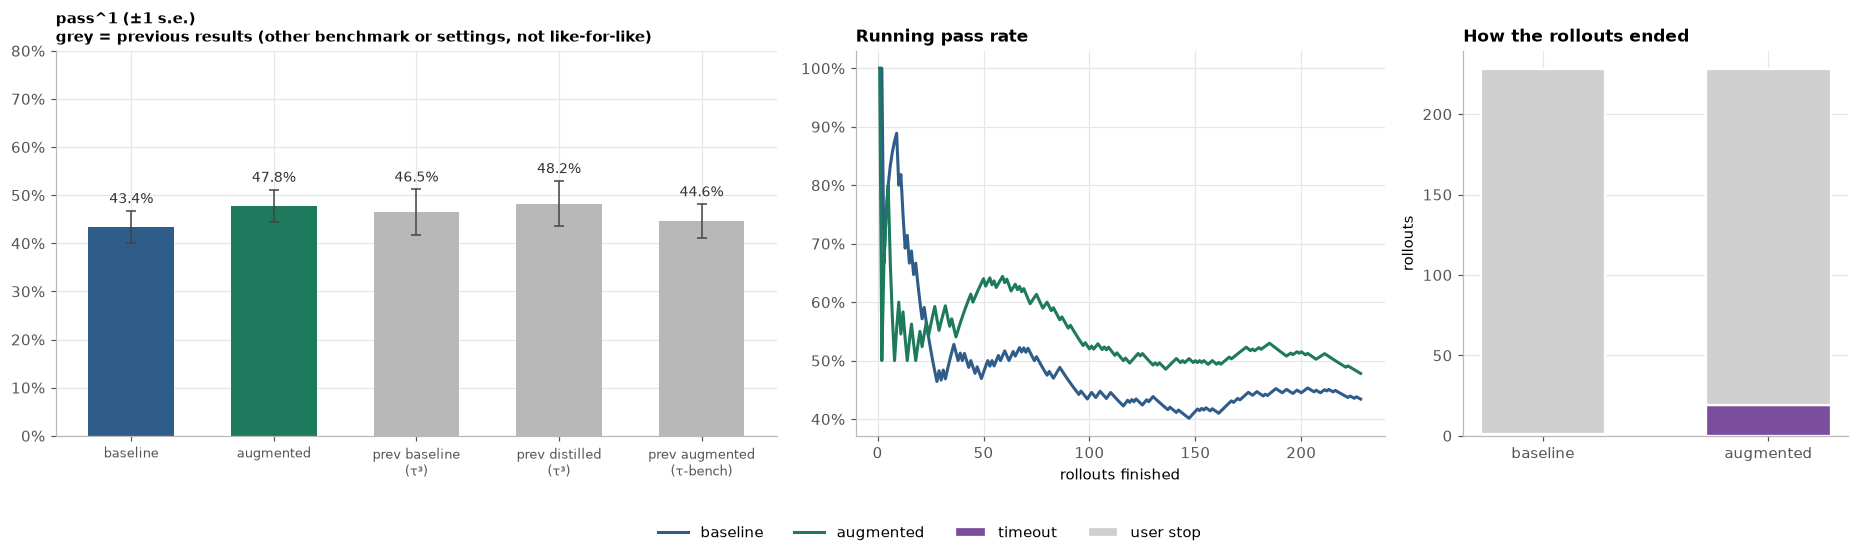

In [13]:
if R4 and (R4["old"]["rollouts_done"] or R4["new"]["rollouts_done"]):
    B4, A4 = R4["old"], R4["new"]
    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw=dict(width_ratios=[1.5, 1.1, 0.8]))
    names, vals, errs, cols = [], [], [], []
    for n, e, c in (("baseline", B4, "#2F5D8A"), ("augmented", A4, "#1E7A5C")):
        if e["rollouts_done"]: names.append(n); vals.append(e["pass1"]); errs.append(e.get("pass1_se") or 0); cols.append(c)
    try:
        old_ref = json.load(open(ROOT / "full_run_results" / "tau3_run.json"))
        for n, k in (("prev baseline (τ³)", "old"), ("prev distilled (τ³)", "new")):
            names.append(n); vals.append(old_ref[k]["pass1"]); errs.append(old_ref[k].get("pass1_se") or 0); cols.append("#B8B8B8")
    except Exception: pass
    try:   # the augmented model's previous result: tau-bench retail, 4 trials (it was never run on tau3 before)
        _by = {}
        for _l in open(ROOT / "sft_aug" / "data" / "retail_aug_4trials_results.jsonl"):
            _r = json.loads(_l); _by.setdefault(_r["task_index"], []).append(1 if _r["reward"] >= 1 else 0)
        _x = [sum(v) / len(v) for v in _by.values()]; _m = sum(_x) / len(_x); _se = (sum((a_ - _m) ** 2 for a_ in _x) / (len(_x) - 1) / len(_x)) ** 0.5
        names.append("prev augmented (τ-bench)"); vals.append(_m); errs.append(_se); cols.append("#B8B8B8")
    except Exception: pass
    b = a1.bar([n.replace(" (", "\n(") for n in names], vals, yerr=errs, color=cols, width=0.6, error_kw=dict(ecolor="#444", elinewidth=1, capsize=3)); bar_labels(a1, b, "{:.1%}", errs)
    a1.set_ylim(0, 0.8); a1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); a1.tick_params(axis="x", labelsize=8.5)
    a1.set_title("pass^1 (±1 s.e.)\ngrey = previous results (other benchmark or settings, not like-for-like)", fontsize=10)
    for n, e, c in (("baseline", B4, "#2F5D8A"), ("augmented", A4, "#1E7A5C")):
        if e["rollouts_done"]: a2.plot(np.arange(1, len(e["running_pass1"]) + 1), e["running_pass1"], color=c, lw=2, label=n)
    a2.set_title("Running pass rate"); a2.set_xlabel("rollouts finished"); a2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    reasons = sorted({k for e in (B4, A4) for k in e.get("terminations", {})}); pal = ["#7A4E9C", "#CFCFCF", "#B3261E", "#E8B04A", "#6B6B6B", "#9DB8D9"]   # kept apart from the model colors
    runs = [(n, e) for n, e in (("baseline", B4), ("augmented", A4)) if e["rollouts_done"]]; bottom = np.zeros(len(runs))
    for i, k in enumerate(reasons):
        v = np.array([e["terminations"].get(k, 0) for _, e in runs], float)
        a3.bar([n for n, _ in runs], v, bottom=bottom, color=pal[i % len(pal)], width=0.55, edgecolor="white", linewidth=1.5, label=k.replace("_", " ")); bottom += v
    a3.set_title("How the rollouts ended"); a3.set_ylabel("rollouts")
    legend_below(fig, 4); plt.show()
else:
    placeholder("τ³ default-settings results", "no rollouts yet")

### τ³: baseline vs augmented, task by task, and per trial

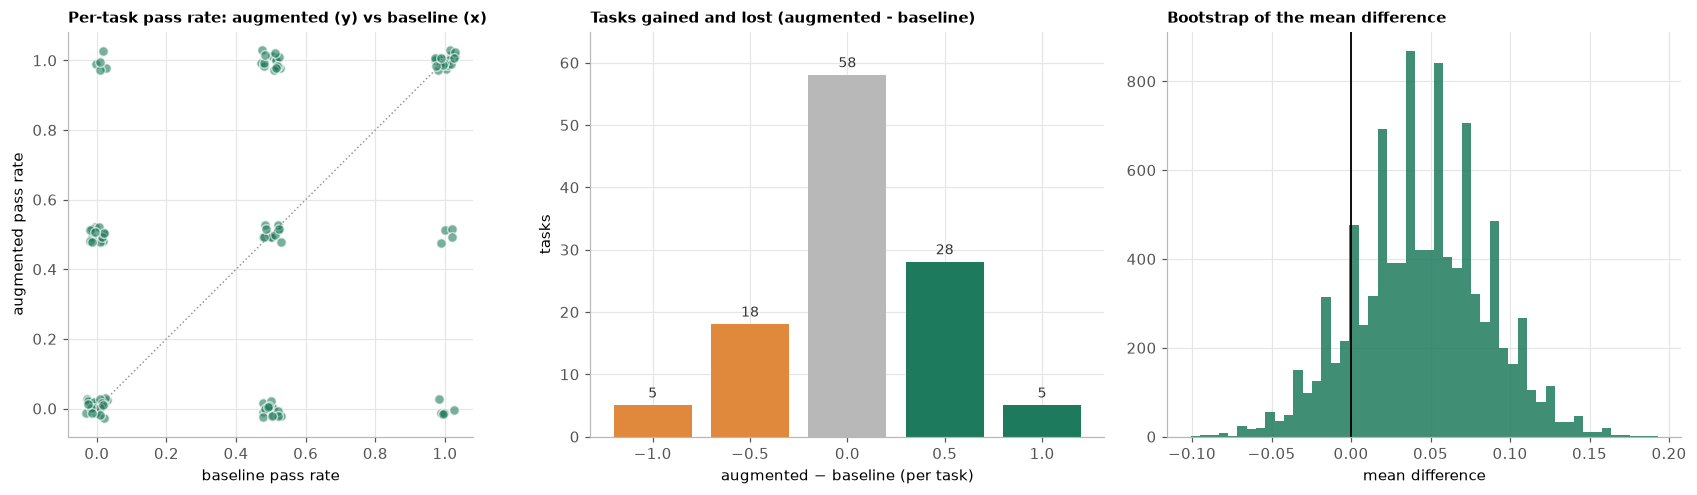

mean difference (augmented - baseline): +0.044, 95% bootstrap interval -0.035 to +0.123, permutation p = 0.334 over 114 tasks


In [14]:
if R4 and R4["old"]["rollouts_done"] and R4["new"]["rollouts_done"]:
    rows_b = {}; rows_a = {}
    for r_ in R4["old"]["rows"]: rows_b.setdefault(r_["task_id"], []).append(1 if (r_.get("reward") or 0) >= 1 else 0)
    for r_ in R4["new"]["rows"]: rows_a.setdefault(r_["task_id"], []).append(1 if (r_.get("reward") or 0) >= 1 else 0)
    tasks = sorted(set(rows_b) & set(rows_a), key=lambda x: int(x) if x.isdigit() else x)
    pb = [np.mean(rows_b[t]) for t in tasks]; pa = [np.mean(rows_a[t]) for t in tasks]
    d = np.array(pa) - np.array(pb); rng = np.random.default_rng(0)
    boots = np.array([rng.choice(d, len(d)).mean() for _ in range(10000)]); flips = np.array([(d * rng.choice([-1, 1], len(d))).mean() for _ in range(10000)])
    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.6))
    rs = np.random.default_rng(1)
    a1.scatter(np.array(pb) + rs.uniform(-.03, .03, len(pb)), np.array(pa) + rs.uniform(-.03, .03, len(pa)), s=40, color="#1E7A5C", alpha=.6, edgecolor="white", linewidth=1)
    a1.plot([0, 1], [0, 1], color="#999", ls=":", lw=1); a1.set_xlabel("baseline pass rate"); a1.set_ylabel("augmented pass rate"); a1.set_aspect("equal")
    a1.set_title("Per-task pass rate: augmented (y) vs baseline (x)", fontsize=10)
    from collections import Counter as _C
    cn = _C(round(x * 2) / 2 for x in d); ks = sorted(cn)
    b = a2.bar(ks, [cn[k] for k in ks], width=0.4, color=["#1E7A5C" if k > 0 else "#E0883B" if k < 0 else "#B8B8B8" for k in ks]); bar_labels(a2, b, "{:.0f}")
    a2.set_xticks(ks); a2.set_xlabel("augmented − baseline (per task)"); a2.set_ylabel("tasks"); a2.set_title("Tasks gained and lost (augmented - baseline)", fontsize=10)
    a3.hist(boots, bins=50, color="#1E7A5C", alpha=.85); a3.axvline(0, color="black", lw=1.2); a3.set_xlabel("mean difference"); a3.set_title("Bootstrap of the mean difference", fontsize=10)
    fig.tight_layout(); plt.show()
    print(f"mean difference (augmented - baseline): {d.mean():+.3f}, 95% bootstrap interval {np.percentile(boots, 2.5):+.3f} to {np.percentile(boots, 97.5):+.3f}, permutation p = {float((np.abs(flips) >= abs(d.mean())).mean()):.3f} over {len(d)} tasks")
else:
    placeholder("τ³ baseline vs augmented", "needs results from both runs")

### τ³: how long and how chatty the rollouts are, and the cost

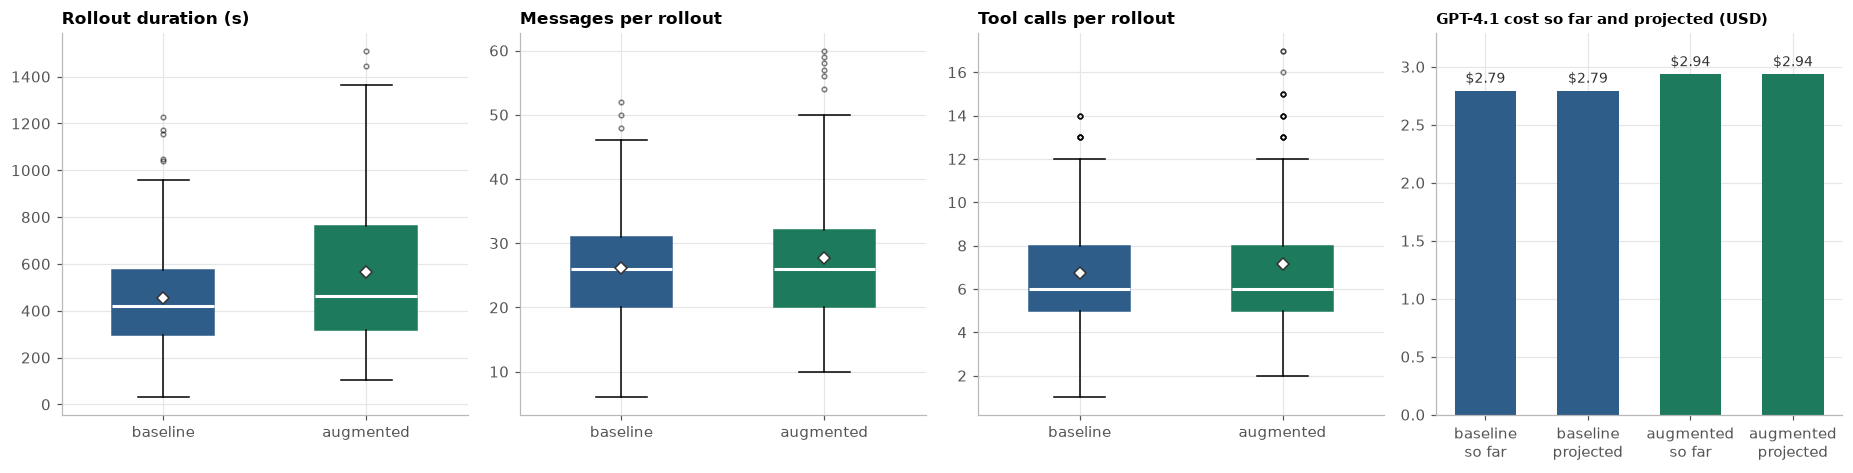

In [15]:
if R4 and (R4["old"]["rollouts_done"] or R4["new"]["rollouts_done"]):
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
    runs = [(n, e, c) for n, e, c in (("baseline", R4["old"], "#2F5D8A"), ("augmented", R4["new"], "#1E7A5C")) if e["rollouts_done"]]
    for ax, key, title in zip(axes, ("duration", "n_messages", "n_tool_calls"), ("Rollout duration (s)", "Messages per rollout", "Tool calls per rollout")):
        bp = ax.boxplot([[r_.get(key) for r_ in e["rows"] if r_.get(key) is not None] for _, e, _ in runs], tick_labels=[n for n, _, _ in runs], widths=0.5, patch_artist=True, showmeans=True,
                        meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333", markersize=6), medianprops=dict(color="white", lw=2), flierprops=dict(marker="o", ms=3, alpha=.5))
        for patch, (_, _, c) in zip(bp["boxes"], runs): patch.set_facecolor(c); patch.set_edgecolor(c)
        ax.set_title(title)
    labels, vals, cols = [], [], []
    for n, e, c in runs:
        per = e["user_cost"] / e["rollouts_done"]; labels += [n + "\nso far", n + "\nprojected"]; vals += [e["user_cost"], per * e["rollouts_total"]]; cols += [c, c]
    b = axes[3].bar(labels, vals, color=cols, width=0.6); bar_labels(axes[3], b, "${:.2f}"); axes[3].set_title("GPT-4.1 cost so far and projected (USD)", fontsize=10)
    fig.tight_layout(); plt.show()
else:
    placeholder("τ³ durations and cost", "no rollouts yet")